In [33]:
%load_ext autoreload
%autoreload 2
import logging
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from bgflow.utils import (assert_numpy, distance_vectors, distances_from_vectors, 
                          remove_mean, IndexBatchIterator, LossReporter, as_numpy, compute_distances
)
from bgflow import (GaussianMCMCSampler, DiffEqFlow, BoltzmannGenerator, Energy, Sampler, 
                    MultiDoubleWellPotential, MeanFreeNormalDistribution, 
                    KernelDynamics,BlackBoxDynamics, TimeIndependentDynamics, BruteForceEstimator, HutchinsonEstimator, DenseNet)

from bgflow.utils.autograd import brute_force_jacobian_trace

from tbg.gcl import E_GCL_vel, E_GCL, GCL
from tbg.models2 import EGNN
from ema_pytorch import EMA

import os
import time
import zuko

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


# first define system dimensionality and a target energy/distribution

dim = 8
n_particles = 4
n_dimensions = dim // n_particles

# DW parameters
a=0.9
b=-4
c=0
offset=4

target = MultiDoubleWellPotential(dim, n_particles, a, b, c, offset, two_event_dims=False)

# define a MCMC sampler to sample from the target energy

dw4_data = np.load("../data/dw4-dataidx.npy", allow_pickle=True)
all_data = remove_mean(dw4_data[0], n_particles, n_dimensions)
idx = dw4_data[1]
data = all_data[idx[:100000]]
val_data = all_data[idx[100000:500000]]
data_holdout = all_data[idx[-500000:]]
data_holdout.shape

dists_data = as_numpy(compute_distances(data, n_particles, n_dimensions))

#plt.hist(dists_data.reshape(-1), bins=100);

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
n_data = 100000
data_smaller = data[:n_data].clone()
dists_data = as_numpy(compute_distances(data_smaller, n_particles, n_dimensions))
sample_dir = "sample/2d_nf"
model_dir = "models/2d_nf"
fig_dir = "figs/2d_nf"

os.makedirs(sample_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

In [35]:
# # now set up a prior
# prior =  MeanFreeNormalDistribution(dim, n_particles, two_event_dims=False).cuda()

# now set up a prior
class MyMeanFreeNormalDistribution(Energy, Sampler):
    """ Mean-free normal distribution. """

    def __init__(self, dim, n_particles, std=1., two_event_dims=True):
        if two_event_dims:
            super().__init__([n_particles, dim // n_particles])
        else:
            super().__init__(dim)
        self._two_event_dims = two_event_dims
        self._dim = dim
        self._n_particles = n_particles
        self._spacial_dims = dim // n_particles
        self.register_buffer("_std", torch.as_tensor(std))

    def forward(self, n_samples, temperature=1.):
        samples = self.sample(n_samples, temperature)
        energy = 0.5 * samples.pow(2).sum(dim=-1, keepdim=True) / self._std ** 2
        return samples, energy.squeeze()
        
    def _energy(self, x):
        x = self._remove_mean(x).view(-1, self._dim)
        # TODO: make consistent
        return 0.5 * x.pow(2).sum(dim=-1, keepdim=True) / self._std ** 2

    def sample(self, n_samples, temperature=1.):
        x = torch.ones((n_samples, self._n_particles, self._spacial_dims), dtype=self._std.dtype,
                         device=self._std.device).normal_(mean=0, std=self._std)
        x = self._remove_mean(x)
        if not self._two_event_dims:
            x = x.view(-1, self._dim)
        return x

    def _remove_mean(self, x):
        x = x.view(-1, self._n_particles, self._spacial_dims)
        x = x - torch.mean(x, dim=1, keepdim=True)
        return x



prior =  MyMeanFreeNormalDistribution(dim, n_particles, two_event_dims=False).cuda()

In [73]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

n_epochs=500
dim = 8
flow = zuko.flows.NSF(features=dim, transforms=12, hidden_features=(256, 256)).cuda()
ema_flow = zuko.flows.NSF(features=dim, transforms=12, hidden_features=(256, 256)).cuda()

ema = EMA(
    flow,
    beta = 0.999,              # exponential moving average factor
    update_after_step = 5_000,    # only after this number of .update() calls will it start updating
    update_every = 1,          # how often to actually update, to save on compute (updates every 10th .update() call)
)

optimizer = torch.optim.AdamW(flow.parameters(), 1e-3)

In [75]:
n_batch = 512
batch_iter = IndexBatchIterator(len(data_smaller), n_batch)

def train():
    i = 0
    for epoch in range(n_epochs):
        for it, idxs in enumerate(batch_iter):
            optimizer.zero_grad()
            x_1 = data_smaller[idxs].cuda()
            loss = - flow().log_prob(x_1).mean()
            loss.backward()
            optimizer.step()
            ema.update()
            i += 1
        if (epoch + 1) % 5 == 0:
                ema_state_dict = {k.replace("ema_model.transform.", "transform.").replace("ema_model.base.", "base."): v for k, v in ema.state_dict().items()}
                ema_flow.load_state_dict(ema_state_dict, strict=False)
                ema_loss = - ema_flow().log_prob(x_1).mean()
                print(f"Step [{epoch+1}/{n_epochs}] - Loss: {loss.item():.4f} - EMA Loss: {ema_loss.item():.4f}")

ema_flow_path = model_dir + f'/ema_flow_v3.pth'
flow_path = model_dir + f'/flow_v3.pth'

if not os.path.exists(flow_path): # if no saved model, train
    train()
    torch.save(flow.state_dict(), flow_path)
    logging.info(f"Model saved to {flow_path}")
    torch.save(ema_flow.state_dict(), ema_flow_path)
    logging.info(f"Model saved to {ema_flow_path}")
else:
    # load saved model
    flow.load_state_dict(torch.load(flow_path))
    logging.info(f"Model loaded from {flow_path}")
    ema_flow.load_state_dict(torch.load(ema_flow_path))
    logging.info(f"Model loaded from {ema_flow_path}")


Step [5/500] - Loss: 4.4760 - EMA Loss: 4.1797
Step [10/500] - Loss: 2.6738 - EMA Loss: 4.1283
Step [15/500] - Loss: 1.5141 - EMA Loss: 1.6657
Step [20/500] - Loss: 2.8552 - EMA Loss: 1.3794
Step [25/500] - Loss: 2.5336 - EMA Loss: 2.4315
Step [30/500] - Loss: 0.5066 - EMA Loss: -0.1897
Step [35/500] - Loss: 0.8396 - EMA Loss: -0.7709
Step [40/500] - Loss: -0.1755 - EMA Loss: -1.2053
Step [45/500] - Loss: -0.3507 - EMA Loss: -1.1976
Step [50/500] - Loss: 0.9855 - EMA Loss: -1.6177
Step [55/500] - Loss: -0.6863 - EMA Loss: -1.5888
Step [60/500] - Loss: -0.7139 - EMA Loss: -1.8337
Step [65/500] - Loss: 1.6758 - EMA Loss: -2.1142
Step [70/500] - Loss: -0.2679 - EMA Loss: -1.8105
Step [75/500] - Loss: -0.7758 - EMA Loss: -2.3530
Step [80/500] - Loss: -1.0664 - EMA Loss: -2.3881
Step [85/500] - Loss: -0.9758 - EMA Loss: -2.4819
Step [90/500] - Loss: 0.2120 - EMA Loss: -2.5591
Step [95/500] - Loss: -1.9848 - EMA Loss: -2.8413
Step [100/500] - Loss: -1.6628 - EMA Loss: -2.6678
Step [105/500] 

KeyboardInterrupt: 

In [76]:
torch.save(flow.state_dict(), flow_path)
logging.info(f"Model saved to {flow_path}")
torch.save(ema_flow.state_dict(), ema_flow_path)
logging.info(f"Model saved to {ema_flow_path}")

2025-01-07 20:27:08,969 - INFO - Model saved to models/2d_nf/flow_v3.pth
2025-01-07 20:27:08,987 - INFO - Model saved to models/2d_nf/ema_flow_v3.pth


In [77]:
#x0 = prior.sample(10000)
#ema_state_dict = {k.replace("ema_model.transform.", "transform.").replace("ema_model.base.", "base."): v for k, v in ema.state_dict().items()}
x1 = flow().sample((100000,))
log_probs = flow().log_prob(x1)

(100000,) torch.Size([100000])


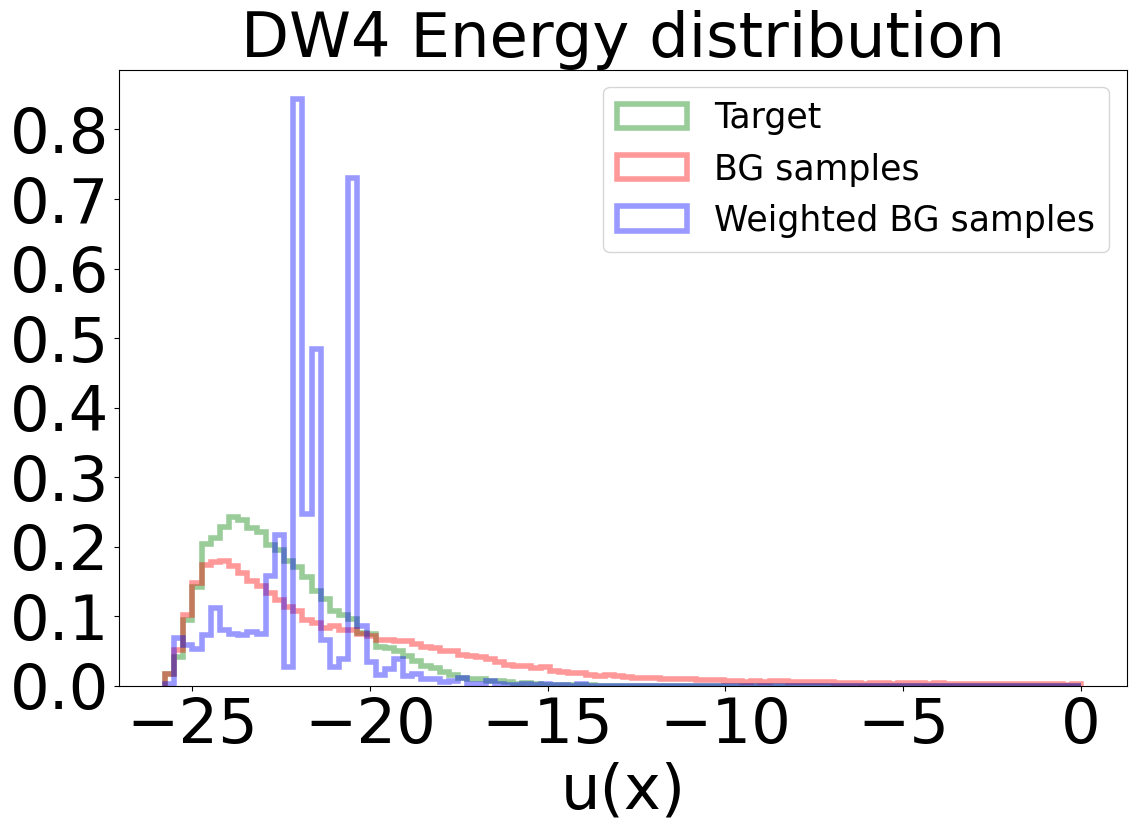

In [91]:
energies_data = target.energy(data).detach().cpu().numpy()
#energies_compare = sampls.energy()
energies_bg = target.energy(x1).detach().cpu().numpy().flatten()
print(energies_bg.shape, log_probs.shape)
log_weights =  - energies_bg - log_probs.detach().cpu().numpy()
#log_weights = bg.log_weights_given_latent(x1, x0, dlogp1.reshape(-1,1), normalize=False).detach().cpu().numpy()
log_w_np = as_numpy(log_weights)
energies_prior = target.energy(data).detach().cpu().numpy()
min_energy = min(energies_data.min(), energies_bg.min(), energies_prior.min())
max_energy = max(energies_data.max(), energies_bg.max(), energies_prior.max())

plt.figure(figsize=(13,8))
efac = 1
#plt.hist(energies_prior, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="b", histtype='step', linewidth=4,
#         label="prior");
plt.hist(energies_data, bins=100, density=True, range=(min_energy, 0), alpha=0.4, color="g", histtype='step', linewidth=4, 
         label="Target");
plt.hist(energies_bg, bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="r", label=f"BG samples");

plt.hist(energies_bg.reshape(-1), bins=100, density=True,  range=(min_energy, 0), alpha=0.4, histtype='step', linewidth=4,
         color="b", label=f"Weighted BG samples", weights=np.exp(log_w_np));
#plt.hist(energies_compare, bins=100, density=True, range=(energies_bg.min(), 0), alpha=0.4, color="y", 
#         label="MCMC data (test)");
plt.title("DW4 Energy distribution", fontsize=45)
plt.xlabel("u(x)", fontsize=45)  
plt.xticks(fontsize=45) 
plt.yticks(fontsize=45);
plt.legend(fontsize=25);

In [85]:
energies_bg

array([ 11.996368, -22.046944, -22.854925, ..., -24.746506, -16.681025,
       -20.919247], shape=(100000,), dtype=float32)

In [86]:
energies_data

array([[-20.032698],
       [-22.73768 ],
       [-18.32373 ],
       ...,
       [-23.264725],
       [-19.408096],
       [-22.277653]], shape=(100000, 1), dtype=float32)